# Passport biodata-page detection from multi-angle OCR

This notebook loads `ocr_8_angles.csv`, searches every OCR angle, and returns one row per image with the matched regex pattern names and a `YES`/`NO` verdict.

## Research basis

- [ICAO Doc 9303, Part 4](https://www.icao.int/sites/default/files/publications/DocSeries/9303_p4_cons_en.pdf) is the operational source for the detector. It defines the passport biodata page, makes the holder portrait and MRZ mandatory, specifies a two-line 44-character TD3 MRZ, and requires the first MRZ character to be `P` for a machine-readable passport.
- [An Overview of Electronic Passport Security Features](https://link.springer.com/chapter/10.1007/978-3-642-03315-5_11) covers e-passport chip and authentication security. It supports the document context, but does not define OCR strings for page classification.
- [Gemalto passport security report](https://www.id4africa.com/2019/almanac/GEMALTO-Joseph-Leibenguth.pdf) discusses the visual zone, MRZ, portrait substitution, and duplicated personalization data. It supports combining several signals instead of trusting one generic label.
- [Passport photo requirements](https://eoivienna.gov.in/public_files/assets/pdf/Passport_Photo_Requirements_230125.pdf) concern portrait composition/quality rather than a unique OCR text pattern.

**Important limitation:** this is a text-only classifier. A positive result means that the image is very likely a passport biodata page, which normally contains the passport portrait. It does not inspect pixels or prove that a face is visible. For literal portrait verification, add a face detector after this text filter.

The decision rule uses the supplied weights: score 0 is `NO`, score 1 is `MAYBE`, and score 2 or more is `YES`.

In [15]:
from pathlib import Path
import re
import unicodedata

import pandas as pd

INPUT_CSV = Path("ocr_8_angles.csv")
OUTPUT_CSV = Path("passport_detection_results_v2.csv")

TEXT_COLUMNS = [
    "text_angle_000",
    "text_angle_045",
    "text_angle_090",
    "text_angle_135",
    "text_angle_180",
    "text_angle_225",
    "text_angle_270",
    "text_angle_315",
]
REQUIRED_COLUMNS = ["image_name", *TEXT_COLUMNS]

## Small regex pattern database

Only the six requested patterns are used. Unique matched-pattern weights are summed across all OCR angles: score 0 is `NO`, score 1 is `MAYBE`, and score 2 or more is `YES`.

In [16]:
PATTERNS = [
    {
        "name": "td3_mrz_pair_strict",
        "target": "mrz_stream",
        "regex": r"P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<][MFX<][0-9]{6}[0-9<][A-Z0-9<]{14}[0-9<]{2}",
        "weight": 2,
        "kind": "mrz",
        "description": "Strict contiguous pair of ICAO TD3 passport MRZ lines (44 + 44 characters).",
    },
    {
        "name": "td3_mrz_upper_line",
        "target": "mrz_lines",
        "regex": r"(?m)^P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}$",
        "weight": 1,
        "kind": "mrz",
        "description": "Exact 44-character upper TD3 line; P is the passport document code.",
    },
    {
        "name": "td3_mrz_lower_line",
        "target": "mrz_lines",
        "regex": r"(?m)^[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<][MFX<][0-9]{6}[0-9<][A-Z0-9<]{14}[0-9<]{2}$",
        "weight": 1,
        "kind": "mrz",
        "description": "Exact 44-character lower TD3 line with document number, nationality, dates, sex and check digits.",
    },
    {
        "name": "passport_word_exact",
        "target": "text_flat",
        "regex": r"\b(?:PASSPORT|PASSEPORT|PASAPORTE)\b",
        "weight": 1,
        "kind": "passport_label",
        "description": "ICAO VIZ passport heading in English, French or Spanish.",
    },
    {
        "name": "passport_word_ocr_tolerant",
        "target": "text_flat",
        "regex": r"\b(?:PAS5PORT|PA5SPORT|PASSP0RT|PASSEP0RT|PASAP0RTE)\b",
        "weight": 1,
        "kind": "passport_label",
        "description": "Common OCR substitutions in the passport heading S->5 and O->0.",
    },
    {
        "name": "passport_number_label",
        "target": "text_flat",
        "regex": r"\b(?:PASSPORT|PASSEPORT|PASAPORTE)\s*(?:NO|NUMBER|NUMERO|N[O0°º])\b",
        "weight": 2,
        "kind": "passport_label",
        "description": "Passport/document number caption.",
    },
]

patterns_df = pd.DataFrame(PATTERNS)
patterns_df[["name", "target", "weight", "kind", "regex", "description"]]

,name,target,weight,kind,regex,description
0,td3_mrz_pair_strict,mrz_stream,2,mrz,P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}[A-Z0-9<]{9}[0-9<...,Strict contiguous pair of ICAO TD3 passport MR...
1,td3_mrz_upper_line,mrz_lines,1,mrz,(?m)^P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}$,Exact 44-character upper TD3 line; P is the pa...
2,td3_mrz_lower_line,mrz_lines,1,mrz,(?m)^[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<]...,Exact 44-character lower TD3 line with documen...
3,passport_word_exact,text_flat,1,passport_label,\b(?:PASSPORT|PASSEPORT|PASAPORTE)\b,"ICAO VIZ passport heading in English, French o..."
4,passport_word_ocr_tolerant,text_flat,1,passport_label,\b(?:PAS5PORT|PA5SPORT|PASSP0RT|PASSEP0RT|PASA...,Common OCR substitutions in the passport headi...
5,passport_number_label,text_flat,2,passport_label,\b(?:PASSPORT|PASSEPORT|PASAPORTE)\s*(?:NO|NUM...,Passport/document number caption.


## Normalization and matching

All eight angles are searched. A pattern contributes its weight at most once per image, even if it appears in several angles. Unicode accents are removed for multilingual Latin labels, and MRZ lines are compacted while preserving the ICAO filler `<`.

In [17]:
FILLER_TRANSLATION = str.maketrans({
    "«": "<", "‹": "<", "＜": "<", "〈": "<", "⟨": "<"
})

def normalize_ocr(value):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.upper().translate(FILLER_TRANSLATION)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text

def build_search_targets(value):
    text = normalize_ocr(value)
    text_flat = re.sub(r"\s+", " ", text).strip()

    # Remove spaces/punctuation introduced inside OCR-B lines. Restrict candidate
    # lengths to avoid treating ordinary short text lines as MRZ lines.
    mrz_candidates = []
    for line in text.splitlines():
        compact = re.sub(r"[^A-Z0-9<]", "", line)
        if 30 <= len(compact) <= 50:
            mrz_candidates.append(compact)

    return {
        "text_flat": text_flat,
        "mrz_lines": "\n".join(mrz_candidates),
        # The stream also catches OCR output where both MRZ lines were returned
        # without a newline. A full 88-character structural match is required.
        "mrz_stream": re.sub(r"[^A-Z0-9<]", "", text),
    }

COMPILED_PATTERNS = {
    item["name"]: re.compile(item["regex"]) for item in PATTERNS
}
PATTERN_BY_NAME = {item["name"]: item for item in PATTERNS}
PATTERN_ORDER = [item["name"] for item in PATTERNS]
def match_one_text(value):
    targets = build_search_targets(value)
    matched = {
        item["name"]
        for item in PATTERNS
        if COMPILED_PATTERNS[item["name"]].search(targets[item["target"]])
    }

    # Exact and OCR-tolerant passport words represent the same evidence.
    if "passport_word_exact" in matched:
        matched.discard("passport_word_ocr_tolerant")
    return matched

def classify_row(row):
    matched_angles = {}
    all_matches = set()

    for column in TEXT_COLUMNS:
        angle_matches = match_one_text(row[column])
        if angle_matches:
            matched_angles[column] = sorted(angle_matches)
            all_matches.update(angle_matches)

    # Apply exact-over-tolerant de-duplication again across angles.
    if "passport_word_exact" in all_matches:
        all_matches.discard("passport_word_ocr_tolerant")

    score = sum(PATTERN_BY_NAME[name]["weight"] for name in all_matches)
    verdict = "YES" if score >= 2 else "MAYBE" if score == 1 else "NO"

    ordered_matches = [name for name in PATTERN_ORDER if name in all_matches]
    return pd.Series({
        "matched_pattern_names": "; ".join(ordered_matches),
        "verdict": verdict,
        "score": score,
        "matched_angles": matched_angles,
    })

## Classify images

`result_df` is the requested three-column output. `diagnostics_df` retains scores and angle-level matches for threshold tuning and error analysis.

In [18]:
ocr_df = pd.read_csv(INPUT_CSV)
ocr_df[TEXT_COLUMNS] = ocr_df[TEXT_COLUMNS].fillna("").astype(str)
classification_df = ocr_df.apply(classify_row, axis=1)

result_df = pd.concat(
    [
        ocr_df[["image_name"]].reset_index(drop=True),
        classification_df[["matched_pattern_names", "verdict"]].reset_index(drop=True),
    ],
    axis=1,
)

diagnostics_df = pd.concat(
    [
        ocr_df[["image_name"]].reset_index(drop=True),
        classification_df.reset_index(drop=True),
    ],
    axis=1,
)

result_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result_df):,} classifications to {OUTPUT_CSV}")
print(result_df["verdict"].value_counts(dropna=False))

Saved 141 classifications to passport_detection_results_v2.csv
verdict
NO       128
MAYBE     11
YES        2
Name: count, dtype: int64


## Inspect borderline and positive cases (optional)

Use this view to review `MAYBE` cases and positive matches before changing the thresholds.

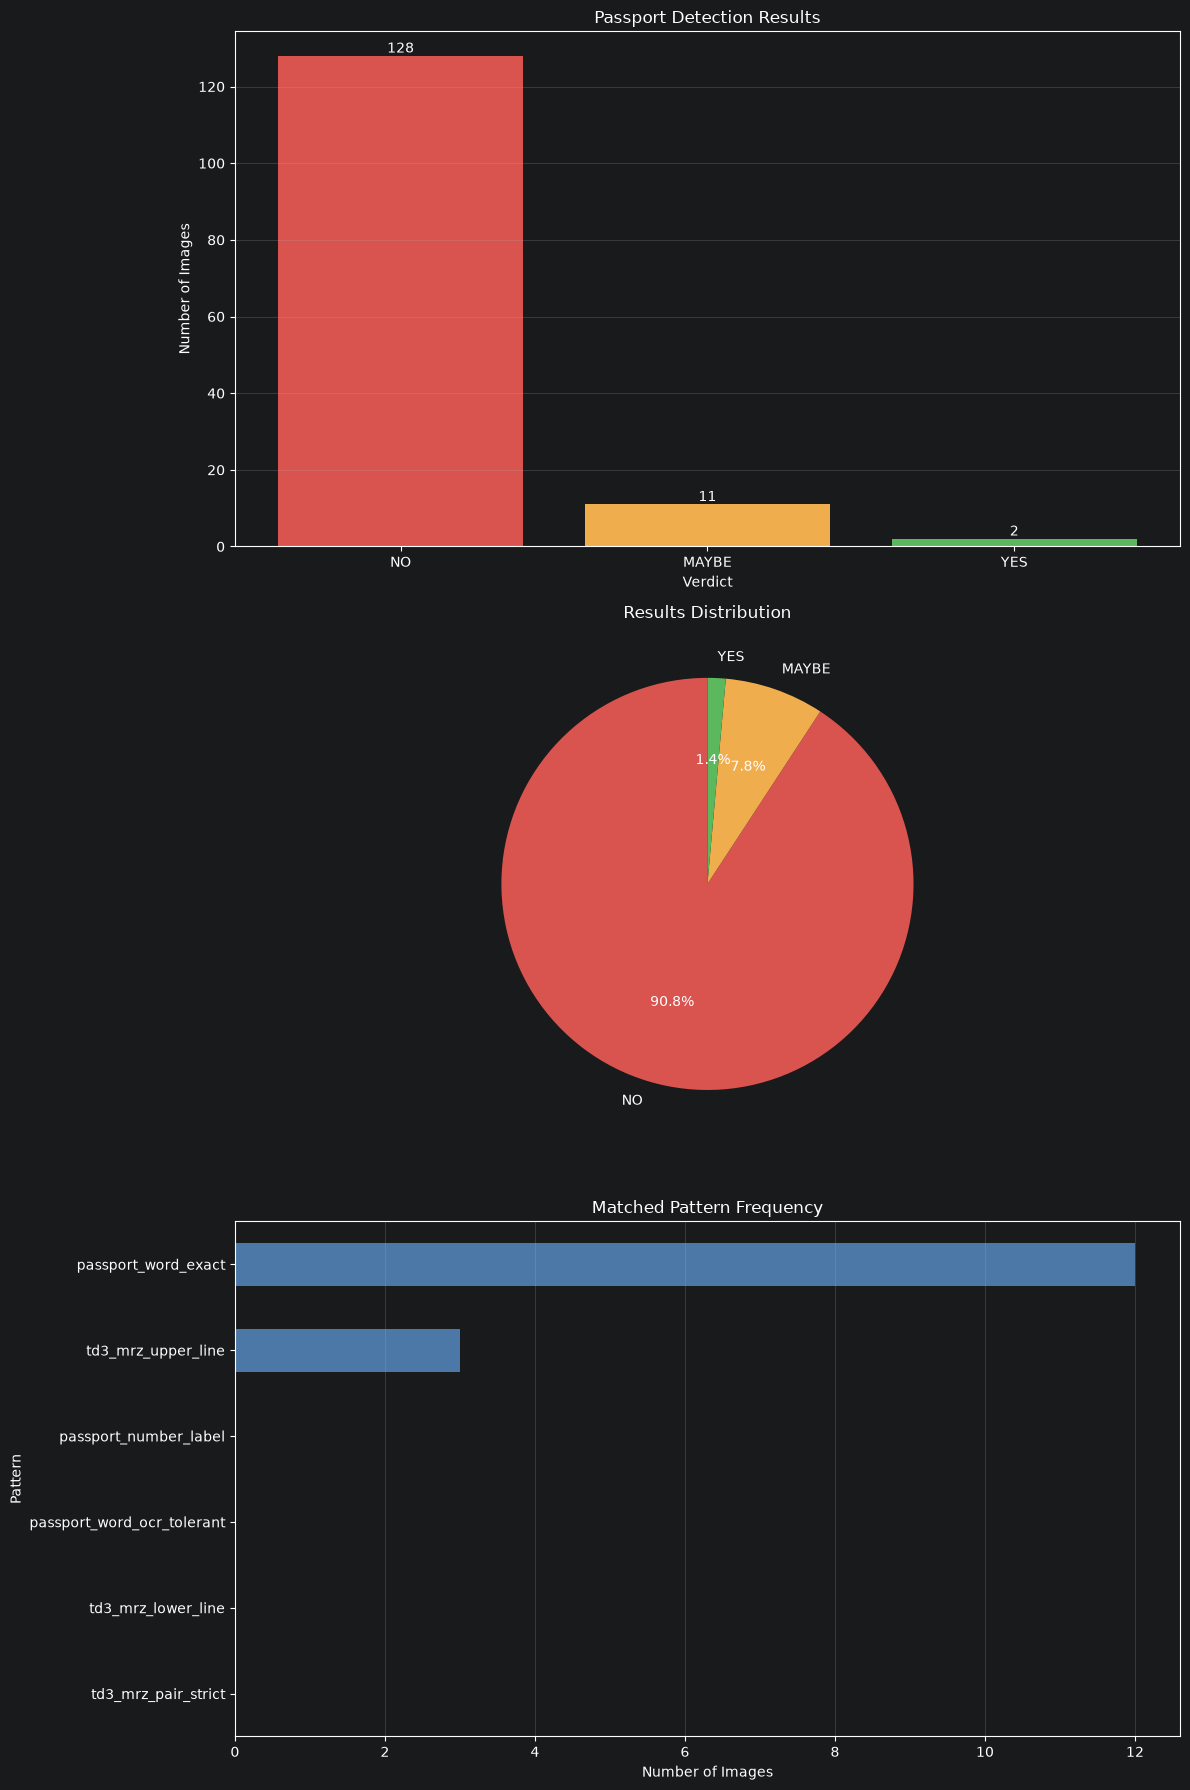

In [19]:
import matplotlib.pyplot as plt

if result_df.empty:
    raise ValueError("result_df is empty")

verdict_order = ["NO", "MAYBE", "YES"]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]

verdict_counts = (
    result_df["verdict"]
    .value_counts()
    .reindex(verdict_order, fill_value=0)
)

pattern_counts = (
    result_df["matched_pattern_names"]
    .fillna("")
    .str.split("; ")
    .explode()
)

pattern_counts = (
    pattern_counts[pattern_counts.ne("")]
    .value_counts()
    .reindex(
        [pattern["name"] for pattern in PATTERNS],
        fill_value=0
    )
    .sort_values()
)

# Three rows, one column
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Verdict counts
bars = axes[0].bar(
    verdict_counts.index,
    verdict_counts.values,
    color=colors
)

axes[0].bar_label(bars)
axes[0].set_title("Passport Detection Results")
axes[0].set_xlabel("Verdict")
axes[0].set_ylabel("Number of Images")
axes[0].grid(axis="y", alpha=0.3)

# 2. Verdict percentages
axes[1].pie(
    verdict_counts.values,
    labels=verdict_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Results Distribution")

# 3. Matched-pattern frequency
pattern_counts.plot(
    kind="barh",
    ax=axes[2],
    color="#4c78a8"
)

axes[2].set_title("Matched Pattern Frequency")
axes[2].set_xlabel("Number of Images")
axes[2].set_ylabel("Pattern")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()